In [99]:
# -*- coding: utf-8 -*-
"""
Created on Thu Jan  2 15:50:57 2025

@author: Pau
"""
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Latex

In [100]:
#Distretization
T = 300 #days
n = 7200 #2400 hours in 100 days
dt = T/n #T/n
t = np.zeros(n+1)

kw = 2.77E-02
kpc = 1.98E-02
ktr = 5.5E-03 #for Cs

vd_cs = 0.0007 * 3600 * 24 #m/s

kre_agri = 10**(-5) * vd_cs * 3600 * 24 #=RFv_d
kre_rice = 0
kre_pasture = np.zeros(n+1)


kl = 1.75E-04
kad = 1.9E-03
kds = 2.1E-04
kup = 1.16E-07
lambda_g = 3.47E-02
lambda_d = np.log(2)/(30.1*365)


#Parameters
f = 0.0548
Be = 0.25
Bf = 0.25
Adep = 0



C_air = np.zeros(n+1)
C_air[:12] = [3.2*10**2, 3.2*10**3, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**4, 3.2*10**3, 3.2*10**2, 0]

vd_cs

60.480000000000004

In [105]:
#Initial conditions
X1 = np.zeros(n+1)
X2 = np.zeros(n+1)
X3 = np.zeros(n+1)
X4 = np.zeros(n+1)
X5 = np.zeros(n+1)
X6 = np.zeros(n+1)

X1[0] = 0 #f*Adep/Bf
X2[0] = 0
X3[0] = 0 #(1-f)*Adep
X4[0] = 0
X5[0] = 0
X6[0] = 0

#Euler method
for i in range(n):
    X1[i+1] = (-(kw + lambda_g + ktr + lambda_d)*X1[i] + kre_agri*f/Bf*X3[i] + (vd_cs*f/Bf)*C_air[i])*dt + X1[i] #Plant surface compartment
    X2[i+1] = (-(lambda_g + lambda_d)*X2[i] + kup/Be*X4[i] + ktr*Bf/Be*X1[i])*dt + X2[i] #Inner tissues
    X3[i+1] = (-(kpc + kre_agri*f + lambda_d)*X3[i] + kw*Bf*X1[i]+ vd_cs*(1-f)*C_air[i])*dt + X3[i] #Surface soil
    X4[i+1] = (-(kl + kup + kad + lambda_d)*X4[i] + kpc*X3[i] + kds*X5[i])*dt + X4[i] #Root zone
    X5[i+1] = (-(kds + lambda_d)*X5[i] + kad*X4[i])*dt + X5[i] #Fix soil
    X6[i+1] = (-(lambda_d)*X1[i] + kl*X4[i])*dt + X6[i] #Deep soil
    t[i+1] = t[i] + dt #Time

vd_cs*f/Bf, vd_cs*(1-f)

(13.257216000000001, 57.165696000000004)

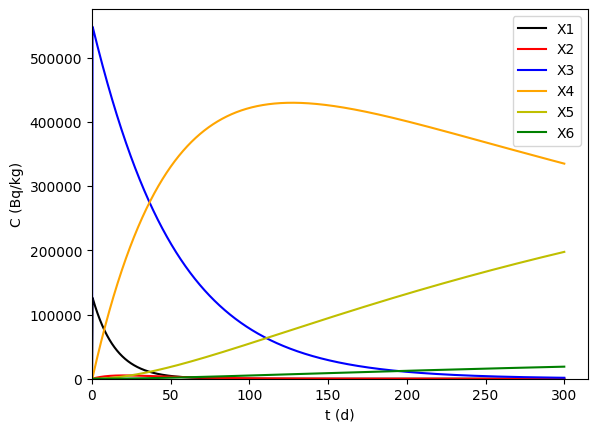

429815.45773995534


In [104]:
#Plot
plt.plot(t, X1, color='black', label = 'X1')
plt.plot(t, X2, color='r', label = 'X2')
plt.plot(t, X3, color='blue', label = 'X3')
plt.plot(t, X4, color='orange', label = 'X4')
plt.plot(t, X5, color='y', label = 'X5')
plt.plot(t, X6, color='g', label = 'X6')
plt.xlabel('t (d)')
plt.xlim(left=0)
plt.ylim(bottom = 0)
plt.ylabel('C (Bq/kg)')
plt.legend(loc = 'upper right')
plt.show()

print(max(X4))